In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("datasets/features_dataset.csv")

In [3]:
df.shape

(336749, 54)

In [4]:
df_corr = df.drop(columns=["URL","File_Extension","Suffix"])

In [5]:
df_corr["Label"] = df_corr["Label"].map({
    "Phishing":1,
    "Legitimate":0
})


In [6]:
corr_matrix = df_corr.corr()

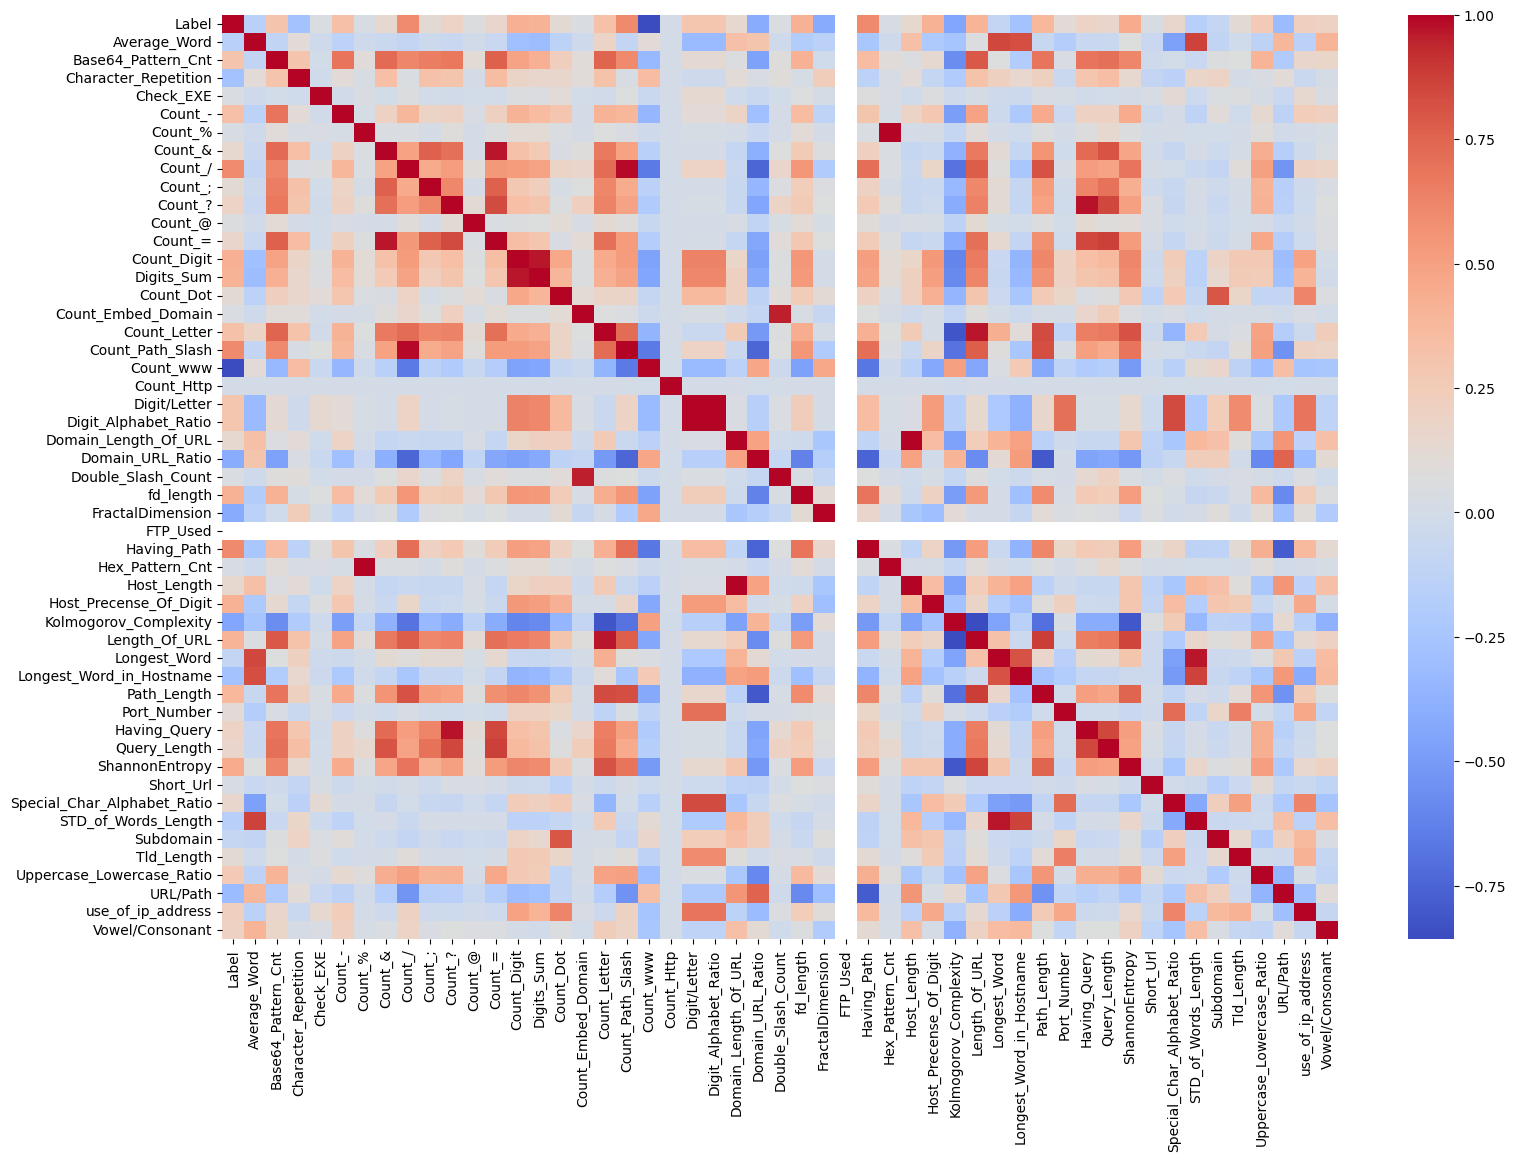

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [8]:
corr_matrix

,Label,Average_Word,Base64_Pattern_Cnt,Character_Repetition,Check_EXE,Count_-,Count_%,Count_&,Count_/,Count_;,...,ShannonEntropy,Short_Url,Special_Char_Alphabet_Ratio,STD_of_Words_Length,Subdomain,Tld_Length,Uppercase_Lowercase_Ratio,URL/Path,use_of_ip_address,Vowel/Consonant
Label,1.000000,-0.158944,0.306546,-0.274269,0.045445,0.329082,0.029694,0.140918,0.599700,0.121874,...,0.443265,0.033377,0.158212,-0.166074,-0.082451,0.122011,0.264537,-0.318123,0.222449,0.197252
Average_Word,-0.158944,1.000000,-0.109471,0.103632,-0.027955,-0.132201,-0.027021,-0.055699,-0.092351,-0.042159,...,0.065004,-0.061129,-0.476367,0.868279,-0.106550,-0.015933,-0.130460,0.387902,-0.144899,0.400786
Base64_Pattern_Cnt,0.306546,-0.109471,1.000000,0.307338,-0.002049,0.692547,0.100103,0.730705,0.616582,0.657823,...,0.621910,-0.029959,-0.002091,-0.066261,0.057658,0.066542,0.402054,-0.201931,0.161644,0.166972
Character_Repetition,-0.274269,0.103632,0.307338,1.000000,-0.017338,0.103086,0.033301,0.338718,0.043766,0.322426,...,0.137669,-0.089880,-0.143052,0.172881,0.192151,0.004521,0.040207,0.105019,-0.053357,0.019665
Check_EXE,0.045445,-0.027955,-0.002049,-0.017338,1.000000,-0.012969,0.040135,-0.006996,0.063671,-0.006050,...,0.004876,0.030612,0.124319,-0.031975,0.044919,0.061018,0.020620,-0.066240,0.138387,0.041839
Count_-,0.329082,-0.132201,0.692547,0.103086,-0.012969,1.000000,0.024375,0.198501,0.386075,0.182705,...,0.444728,-0.044145,0.009881,-0.120849,0.099306,-0.016202,0.131659,-0.130241,0.244809,0.222928
Count_%,0.029694,-0.027021,0.100103,0.033301,0.040135,0.024375,1.000000,0.046538,0.049591,0.019616,...,0.057997,0.002502,0.013642,-0.006284,-0.007028,0.008430,0.081979,-0.010140,0.001877,0.023862
Count_&,0.140918,-0.055699,0.730705,0.338718,-0.006996,0.198501,0.046538,1.000000,0.497103,0.762589,...,0.481157,-0.009551,-0.076598,0.010859,-0.030072,0.017218,0.440371,-0.173070,-0.027361,0.042733
Count_/,0.599700,-0.092351,0.616582,0.043766,0.063671,0.386075,0.049591,0.497103,1.000000,0.451080,...,0.694912,0.014186,-0.002349,-0.054392,-0.093532,0.088412,0.502831,-0.534396,0.202783,0.182215
Count_;,0.121874,-0.042159,0.657823,0.322426,-0.006050,0.182705,0.019616,0.762589,0.451080,1.000000,...,0.432659,-0.024215,-0.072837,0.014281,-0.024699,0.016304,0.409311,-0.161566,-0.024139,0.036479


In [9]:
import numpy as np

corr_matrix = df_corr.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [column for column in upper.columns if any(upper[column] > 0.90)]

high_corr_features

['Count_=',
 'Digits_Sum',
 'Count_Path_Slash',
 'Digit_Alphabet_Ratio',
 'Double_Slash_Count',
 'Hex_Pattern_Cnt',
 'Host_Length',
 'Length_Of_URL',
 'Having_Query',
 'STD_of_Words_Length']

In [10]:
df_reduced = df_corr.drop(columns=high_corr_features)

In [11]:
df_reduced.shape

(336749, 41)

In [12]:
# Random Forest feature importance Start

In [27]:
X = df_reduced.drop(columns=["Label"])
y = df_reduced["Label"]

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [29]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Count_www                      1.810125e-01
Path_Length                    1.334846e-01
Count_/                        1.156505e-01
Domain_URL_Ratio               9.275291e-02
URL/Path                       6.511276e-02
Character_Repetition           5.321260e-02
Having_Path                    4.267598e-02
fd_length                      4.257024e-02
Count_Digit                    3.110316e-02
FractalDimension               2.894607e-02
Digit/Letter                   2.680538e-02
Kolmogorov_Complexity          2.669426e-02
Domain_Length_Of_URL           2.455868e-02
Longest_Word                   2.061861e-02
Count_Letter                   1.838048e-02
ShannonEntropy                 1.610532e-02
Host_Precense_Of_Digit         1.329594e-02
Tld_Length                     1.278702e-02
Longest_Word_in_Hostname       9.523371e-03
Special_Char_Alphabet_Ratio    9.060406e-03
Average_Word                   8.166981e-03
Count_Dot                      6.306833e-03
Count_-                        5

In [30]:
feature_importance.head(20)

Count_www                      0.181012
Path_Length                    0.133485
Count_/                        0.115651
Domain_URL_Ratio               0.092753
URL/Path                       0.065113
Character_Repetition           0.053213
Having_Path                    0.042676
fd_length                      0.042570
Count_Digit                    0.031103
FractalDimension               0.028946
Digit/Letter                   0.026805
Kolmogorov_Complexity          0.026694
Domain_Length_Of_URL           0.024559
Longest_Word                   0.020619
Count_Letter                   0.018380
ShannonEntropy                 0.016105
Host_Precense_Of_Digit         0.013296
Tld_Length                     0.012787
Longest_Word_in_Hostname       0.009523
Special_Char_Alphabet_Ratio    0.009060
dtype: float64

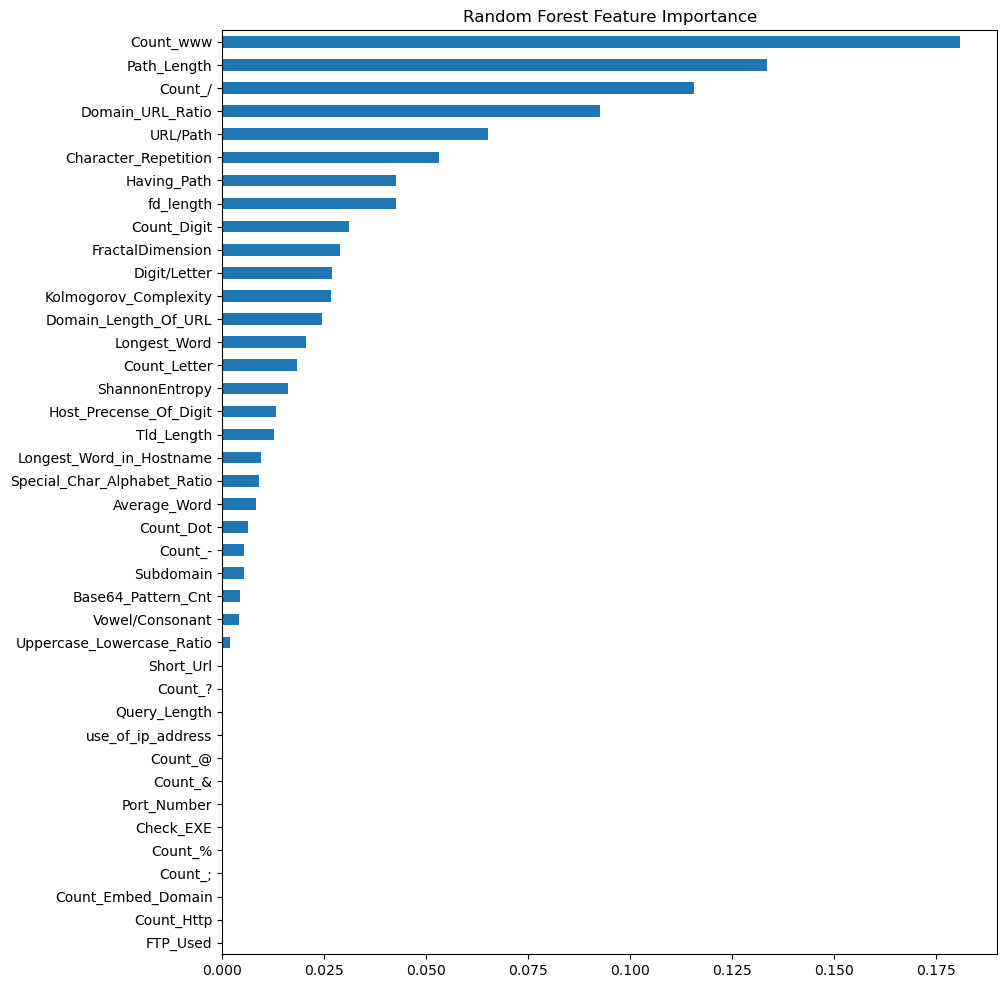

In [31]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(10,12)
)

plt.title("Random Forest Feature Importance")
plt.show()

In [33]:
# Düşük Skorları kaldır
important_features = feature_importance[feature_importance > 0.01].index

X_selected = X[important_features]

In [34]:
df_final = pd.concat([X_selected, y], axis=1)

In [35]:
df_final.shape

(336749, 19)

In [41]:
df_final.columns

Index(['Count_www', 'Path_Length', 'Count_/', 'Domain_URL_Ratio', 'URL/Path',
       'Character_Repetition', 'Having_Path', 'fd_length', 'Count_Digit',
       'FractalDimension', 'Digit/Letter', 'Kolmogorov_Complexity',
       'Domain_Length_Of_URL', 'Longest_Word', 'Count_Letter',
       'ShannonEntropy', 'Host_Precense_Of_Digit', 'Tld_Length', 'Label'],
      dtype='object')

In [ ]:
-------------------------

In [38]:
#5-Fold Cross Validation

In [39]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. En iyi 20 özelliğini seçiyoruz (feature_importance listendeki ilk 20 isim)
top_20_features = feature_importance.head(20).index.tolist()
X_selected = X[top_20_features]

# 2. Modelimizi tanımlıyoruz (Daha önce kullandığın parametrelerle)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. 5-Katlı Çapraz Doğrulama (5-Fold Cross Validation)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(rf_final, X_selected, y, cv=kf, scoring='accuracy')

# 4. Sonuçları yazdırıyoruz
print(f"Her bir katman için Accuracy skorları: {cv_results}")
print(f"Ortalama Accuracy: %{cv_results.mean()*100:.2f}")
print(f"Standart Sapma: {cv_results.std():.4f}")

Her bir katman için Accuracy skorları: [0.99747587 0.99728285 0.99732739 0.99737194 0.99744614]
Ortalama Accuracy: %99.74
Standart Sapma: 0.0001


In [44]:
df_final.to_csv("datasets/dataset_final.csv", index=False)